In [ ]:
import torch
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

tfds.core.DatasetInfo(
    name='rock_paper_scissors',
    full_name='rock_paper_scissors/3.0.0',
    description="""
    Images of hands playing rock, paper, scissor game.
    """,
    homepage='http://laurencemoroney.com/rock-paper-scissors-dataset',
    data_dir='/root/tensorflow_datasets/rock_paper_scissors/3.0.0',
    file_format=tfrecord,
    download_size=219.53 MiB,
    dataset_size=219.23 MiB,
    features=FeaturesDict({
        'image': Image(shape=(300, 300, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=3),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=372, num_shards=1>,
        'train': <SplitInfo num_examples=2520, num_shards=2>,
    },
    citation="""@ONLINE {rps,
    author = "Laurence Moroney",
    title = "Rock, Paper, Scissors Dataset",
    month = "feb",
    year = "2019",
    url = "http://laurencemoroney.com/rock

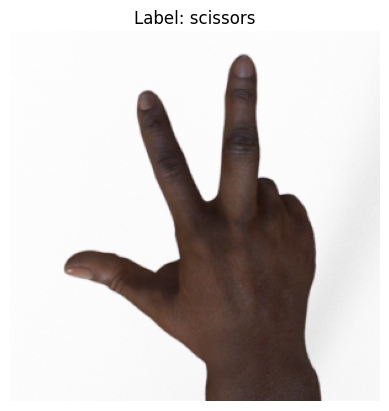

In [ ]:
# ==========================================
# تحميل Rock Paper Scissors Dataset مباشرة
# من TensorFlow Datasets داخل Google Colab
# ==========================================

# تثبيت TensorFlow Datasets (إذا لم يكن مثبتًا)
!pip install -q tensorflow-datasets

import tensorflow_datasets as tfds
import os

# ==========================================
# تحميل البيانات
# as_supervised=True  => يرجع (image, label)
# with_info=True      => يرجع معلومات عن الـ dataset
# ==========================================
(dataset_train, dataset_test), info = tfds.load(
    'rock_paper_scissors',
    split=['train', 'test'],
    as_supervised=True,
    with_info=True
)

# ==========================================
# عرض معلومات عن البيانات
# ==========================================
print(info)

print("Classes:", info.features['label'].names)
print("Number of Classes:", info.features['label'].num_classes)
print("Training Samples:", info.splits['train'].num_examples)
print("Testing Samples :", info.splits['test'].num_examples)

# ==========================================
# تحويل أسماء الكلاسات إلى قائمة
# ==========================================
class_names = info.features['label'].names
print("Class Names:", class_names)

# ==========================================
# حفظ البيانات محليًا (اختياري)
# TensorFlow Datasets يخزنها تلقائيًا في:
# /root/tensorflow_datasets/
# ==========================================
print("Dataset saved automatically in:")
print(os.path.expanduser("~/tensorflow_datasets"))

# ==========================================
# مثال على عرض أول صورة
# ==========================================
import matplotlib.pyplot as plt

for image, label in dataset_train.take(1):
    plt.imshow(image.numpy())
    plt.title(f"Label: {class_names[label.numpy()]}")
    plt.axis("off")
    plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import transforms

import tensorflow_datasets as tfds

import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),

    # 🔥 Augmentation قوية
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),

    transforms.ToTensor(),

    # Normalization
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

In [ ]:
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader

class TFDSDataset(Dataset):
    def __init__(self, tf_dataset, transform=None):
        self.data = []
        self.transform = transform

        # نحفظ البيانات في الذاكرة مرة واحدة
        for image, label in tf_dataset:
            self.data.append((image.numpy(), label.numpy()))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image, label = self.data[idx]

        # تحويل NumPy array إلى PIL Image
        image = Image.fromarray(image)

        # تطبيق الـ transforms
        if self.transform:
            image = self.transform(image)

        return image, label


# إنشاء datasets باستخدام transforms
train_data = TFDSDataset(dataset_train, transform=train_transform)
test_data  = TFDSDataset(dataset_test, transform=test_transform)

# DataLoaders
batch_size = 32

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Test batches :", len(test_loader))

Train batches: 79
Test batches : 12


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)

        # 🔥 Dropout أقوى
        self.dropout = nn.Dropout(0.5)

        self.flatten = nn.Flatten()
        self.fc1 = nn.LazyLinear(256)
        self.fc2 = nn.Linear(256, 3)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = self.flatten(x)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNModel().to(device)

print(model)

CNNModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): LazyLinear(in_features=0, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=3, bias=True)
)


In [ ]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = model.to(device)

cuda


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        # نقل البيانات إلى GPU أو CPU
        images = images.to(device)
        labels = labels.to(device)

        # تصفير الـ gradients
        optimizer.zero_grad()

        # Forward Pass
        outputs = model(images)

        # حساب الـ Loss
        loss = criterion(outputs, labels)

        # Backward Pass
        loss.backward()

        # تحديث الأوزان
        optimizer.step()

        # تجميع الـ Loss
        running_loss += loss.item()

        # حساب Accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    # أثناء التقييم لا نحسب gradients
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            # Forward Pass
            outputs = model(images)

            # حساب Loss
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            # حساب Accuracy
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [ ]:
patience = 4
counter = 0

best_test_acc = 0
best_epoch = 0

train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(20):  # ممكن نزود epochs

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    test_loss, test_acc = evaluate(
        model, test_loader, criterion, device
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch [{epoch+1}]")
    print(f"Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

    # 🔥 حفظ أفضل موديل
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch + 1
        counter = 0

        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Saved Best Model")

    else:
        counter += 1
        print(f"⚠ No improvement: {counter}/{patience}")

    # ⛔ Early Stopping
    if counter >= patience:
        print("🛑 Early Stopping Triggered")
        break

print("================================")
print(f"Best Accuracy: {best_test_acc:.2f}% at epoch {best_epoch}")
print("================================")

Epoch [1]
Train Acc: 54.60% | Test Acc: 46.24%
✅ Saved Best Model
Epoch [2]
Train Acc: 78.57% | Test Acc: 66.40%
✅ Saved Best Model
Epoch [3]
Train Acc: 87.50% | Test Acc: 82.26%
✅ Saved Best Model
Epoch [4]
Train Acc: 90.00% | Test Acc: 87.90%
✅ Saved Best Model
Epoch [5]
Train Acc: 93.13% | Test Acc: 91.40%
✅ Saved Best Model
Epoch [6]
Train Acc: 94.64% | Test Acc: 90.59%
⚠ No improvement: 1/4
Epoch [7]
Train Acc: 94.76% | Test Acc: 74.19%
⚠ No improvement: 2/4
Epoch [8]
Train Acc: 93.81% | Test Acc: 90.05%
⚠ No improvement: 3/4
Epoch [9]
Train Acc: 93.97% | Test Acc: 96.77%
✅ Saved Best Model
Epoch [10]
Train Acc: 95.36% | Test Acc: 97.58%
✅ Saved Best Model
Epoch [11]
Train Acc: 96.15% | Test Acc: 95.70%
⚠ No improvement: 1/4
Epoch [12]
Train Acc: 96.47% | Test Acc: 87.63%
⚠ No improvement: 2/4
Epoch [13]
Train Acc: 96.07% | Test Acc: 77.15%
⚠ No improvement: 3/4
Epoch [14]
Train Acc: 96.47% | Test Acc: 98.12%
✅ Saved Best Model
Epoch [15]
Train Acc: 96.94% | Test Acc: 97.58%
⚠ No 

In [ ]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

CNNModel(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.5, inplace=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=3, bias=True)
)

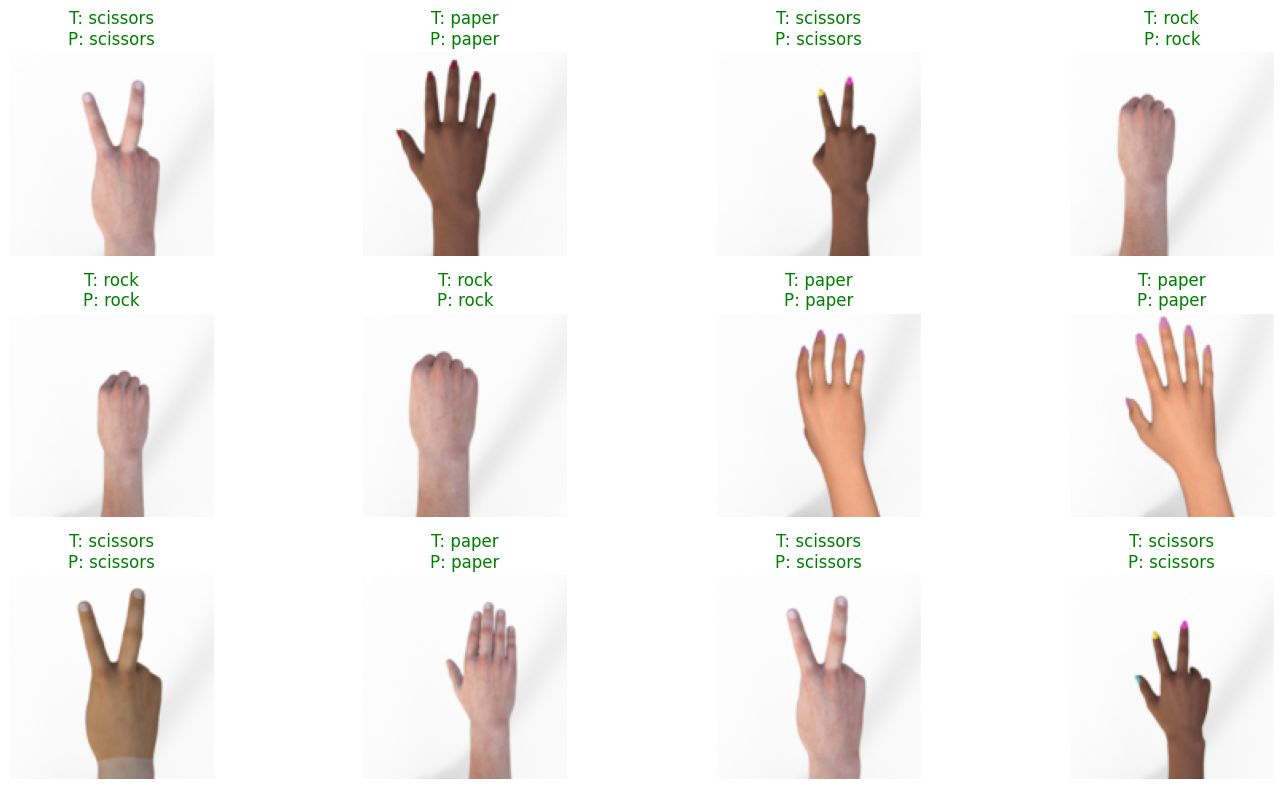

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class_names = ['rock', 'paper', 'scissors']

# خد batch من test
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

plt.figure(figsize=(15, 8))

for i in range(12):
    plt.subplot(3, 4, i+1)

    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5) + 0.5  # unnormalize
    img = np.clip(img, 0, 1)

    plt.imshow(img)

    true_label = class_names[labels[i]]
    pred_label = class_names[preds[i]]

    color = "green" if true_label == pred_label else "red"

    plt.title(f"T: {true_label}\nP: {pred_label}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

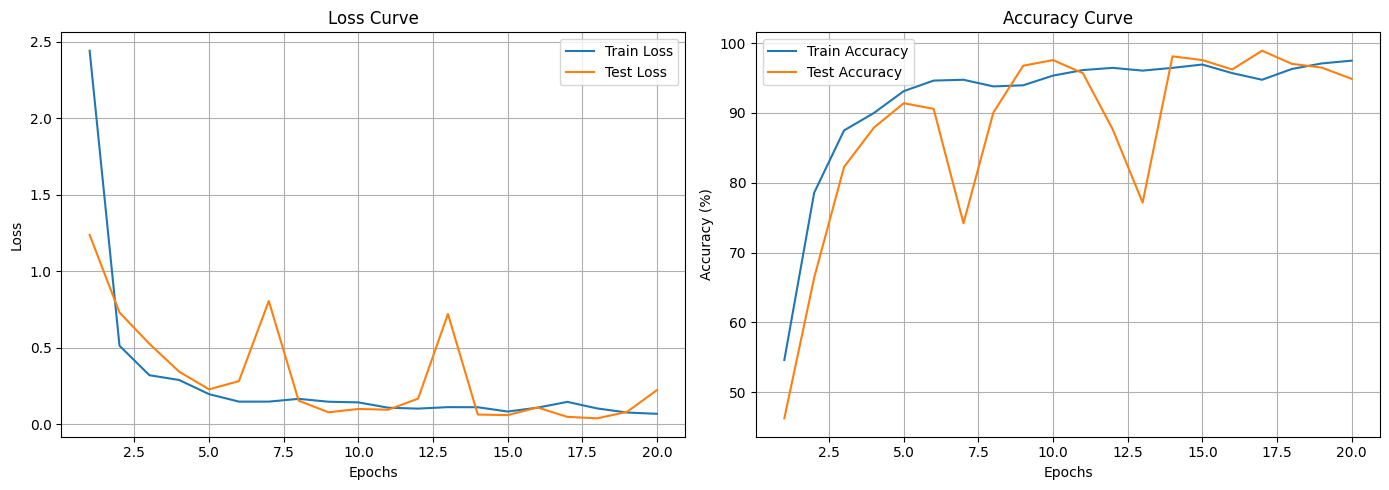

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(14, 5))

# ---------------- LOSS ----------------
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, test_losses, label="Test Loss")
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# ---------------- ACCURACY ----------------
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accs, label="Train Accuracy")
plt.plot(epochs_range, test_accs, label="Test Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# أفضل Test Accuracy في التجربة الأولى (Adam)
best_test_accuracy = max(test_accs)

# رقم الـ Epoch الذي حقق أفضل نتيجة
best_epoch = test_accs.index(best_test_accuracy) + 1

# الـ Loss المقابل لأفضل Accuracy
best_test_loss = test_losses[best_epoch - 1]

print(f"Best Epoch: {best_epoch}")
print(f"Best Test Accuracy: {best_test_accuracy:.2f}%")
print(f"Best Test Loss: {best_test_loss:.4f}")

Best Epoch: 17
Best Test Accuracy: 98.92%
Best Test Loss: 0.0481


<Figure size 600x600 with 0 Axes>

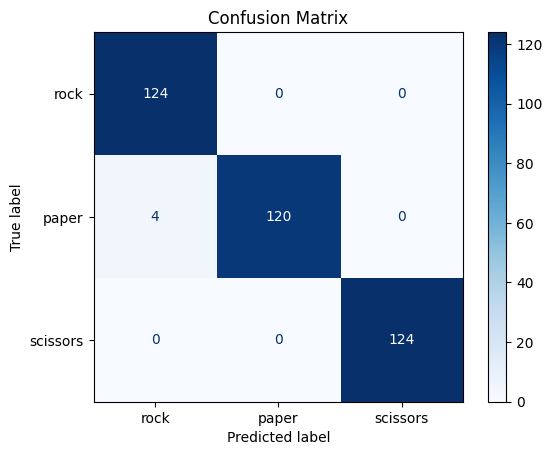

Classification Report:
              precision    recall  f1-score   support

        rock       0.97      1.00      0.98       124
       paper       1.00      0.97      0.98       124
    scissors       1.00      1.00      1.00       124

    accuracy                           0.99       372
   macro avg       0.99      0.99      0.99       372
weighted avg       0.99      0.99      0.99       372



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import torch
import numpy as np

# أسماء الكلاسات في Dataset
class_names = ['rock', 'paper', 'scissors']

# تحميل أفضل موديل محفوظ
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# قوائم لتخزين النتائج الحقيقية والمتوقعة
y_true = []
y_pred = []

# المرور على كل بيانات الاختبار
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        # التنبؤ
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        # حفظ النتائج
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# إنشاء Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# عرض المصفوفة
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=class_names)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

# تقرير تفصيلي (Precision, Recall, F1-score)
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CNNModelV2(nn.Module):
    def __init__(self):
        super(CNNModelV2, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)

        # Dropout أقل من النموذج الأول
        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, 3)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        x = self.fc2(x)
        return x

In [ ]:
model_v2 = CNNModelV2().to(device)

optimizer = torch.optim.Adam(
    model_v2.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

In [ ]:
# عدد الـ epochs
epochs = 20

# قوائم خاصة بالتجربة الثانية
train_losses_v2, test_losses_v2 = [], []
train_accs_v2, test_accs_v2 = [], []

# متغيرات حفظ أفضل نتيجة
best_test_acc = 0
best_epoch = 0
patience = 4
counter = 0

for epoch in range(epochs):
    # Training
    train_loss, train_acc = train_one_epoch(
        model_v2,
        train_loader,
        optimizer,
        criterion,
        device
    )

    # Evaluation
    test_loss, test_acc = evaluate(
        model_v2,
        test_loader,
        criterion,
        device
    )

    # حفظ النتائج للرسم
    train_losses_v2.append(train_loss)
    test_losses_v2.append(test_loss)
    train_accs_v2.append(train_acc)
    test_accs_v2.append(test_acc)

    # طباعة النتائج
    print(f"Epoch [{epoch+1}]")
    print(f"Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

    # حفظ أفضل موديل
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_epoch = epoch + 1
        torch.save(model_v2.state_dict(), "best_model_v2.pth")
        print("✅ Saved Best Model")
        counter = 0
    else:
        counter += 1
        print(f"⚠ No improvement: {counter}/{patience}")

    # Early Stopping
    if counter >= patience:
        print("🛑 Early Stopping Triggered")
        break

print("=" * 32)
print(f"Best Accuracy: {best_test_acc:.2f}% at epoch {best_epoch}")
print("=" * 32)

Epoch [1]
Train Acc: 64.48% | Test Acc: 80.38%
✅ Saved Best Model
Epoch [2]
Train Acc: 91.94% | Test Acc: 86.29%
✅ Saved Best Model
Epoch [3]
Train Acc: 95.83% | Test Acc: 88.98%
✅ Saved Best Model
Epoch [4]
Train Acc: 96.39% | Test Acc: 88.17%
⚠ No improvement: 1/4
Epoch [5]
Train Acc: 97.94% | Test Acc: 92.74%
✅ Saved Best Model
Epoch [6]
Train Acc: 97.10% | Test Acc: 92.74%
⚠ No improvement: 1/4
Epoch [7]
Train Acc: 97.42% | Test Acc: 83.60%
⚠ No improvement: 2/4
Epoch [8]
Train Acc: 98.73% | Test Acc: 89.78%
⚠ No improvement: 3/4
Epoch [9]
Train Acc: 98.25% | Test Acc: 85.75%
⚠ No improvement: 4/4
🛑 Early Stopping Triggered
Best Accuracy: 92.74% at epoch 5


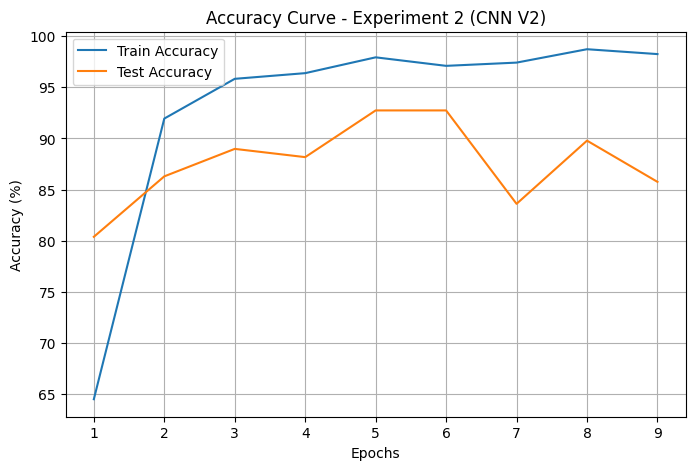

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_accs_v2) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs_range, train_accs_v2, label="Train Accuracy")
plt.plot(epochs_range, test_accs_v2, label="Test Accuracy")

plt.title("Accuracy Curve - Experiment 2 (CNN V2)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

plt.show()

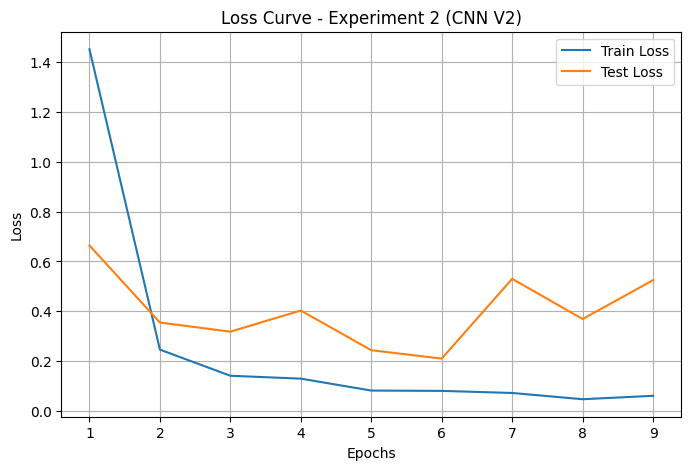

In [ ]:
plt.figure(figsize=(8,5))

epochs_range = range(1, len(train_losses_v2) + 1)

plt.plot(epochs_range, train_losses_v2, label="Train Loss")
plt.plot(epochs_range, test_losses_v2, label="Test Loss")

plt.title("Loss Curve - Experiment 2 (CNN V2)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()